# 11 -- Ensemble: no-lag + with-lag

**Идея:**
- `no-lag` сигнал — pure fair value (slow-moving), R²=0.524
- `with-lag` сигнал — короткий mean-reversion над autoregressive baseline, R²=0.796
- Они ловят разное → combo может убрать шум одного и оставить consensus

**Литература (forecast combination):**
- Bates & Granger (1969) — classic combo
- Stock & Watson (2004) — combination forecasts in macroeconomics
- Rapach, Strauss, Zhou (RFS 2010) — combining stock return forecasts beats individual

**Что тестируем (на foundation Q5 ∩ Quality > 0, monthly equal, best Week 1+2):**
| Variant | Логика |
|---|---|
| **V11a** | average z: ранжируем по (z_no_lag + z_with_lag) / 2 |
| **V11b** | intersection: Q5 в обеих моделях (top-quintile by both) |
| **V11c** | conditional: z_no_lag > 1.5 AND z_with_lag > 1.0 (asymmetric thresholds) |
| **V11d** | disagreement filter: остаются bonds, где обе модели соглашаются |
| **V11e** | combo W2: ensemble + Quarterly + z-weighted (всё лучшее)|

**Baseline для сравнения:** V10c (quarterly equal на no-lag) и V10f (full combo). Если ensemble не лучше — фиксируем negative finding, идём в Week 3.

## Часть 1. Setup и загрузка двух signals

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
np.random.seed(42)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Загружаем обе модели
sig_no = sl.load_signal_full('no_lag')
sig_wl = sl.load_signal_full('with_lag')
print(f'no_lag : {sig_no.shape}')
print(f'with_lag: {sig_wl.shape}')

# Сливаем mispricing/z от обеих моделей в один df
wl_sub = sig_wl[['date', 'isin', 'mispricing', 'mispricing_z', 'mispricing_quintile']].copy()
wl_sub.columns = ['date', 'isin', 'mispricing_wl', 'mispricing_z_wl', 'mispricing_quintile_wl']
sig = sig_no.merge(wl_sub, on=['date', 'isin'], how='inner')
sig = sig.rename(columns={'mispricing': 'mispricing_nl',
                            'mispricing_z': 'mispricing_z_nl',
                            'mispricing_quintile': 'mispricing_quintile_nl'})

# Ensemble signals
sig['mispricing_avg_z'] = (sig['mispricing_z_nl'] + sig['mispricing_z_wl']) / 2
sig['mispricing'] = sig['mispricing_nl']  # для default ranking

sig = sl.compute_quality_score(sig)
bench = sl.load_benchmarks()
main = sig[sig['date'] <= sl.MAIN_END].copy()
mask_quality = main['quality_z'] > 0
print(f'\nMerged: {sig.shape}, main: {main.shape}')
print(f'Correlation z_nl vs z_wl: {sig[["mispricing_z_nl", "mispricing_z_wl"]].corr().iloc[0,1]:.3f}')

no_lag : (277966, 30)
with_lag: (277966, 30)

Merged: (277966, 37), main: (213445, 37)
Correlation z_nl vs z_wl: 0.451


## Часть 2. Разведка: насколько модели согласуются?

Если высокая корреляция между z-scores — ensemble не даст ничего нового. Если низкая — есть смысл.

Total no-lag Q5 observations: 55,830
Total with-lag Q5 observations: 55,830
Intersection (in both Q5): 27,710
Overlap rate vs no-lag Q5: 49.6%


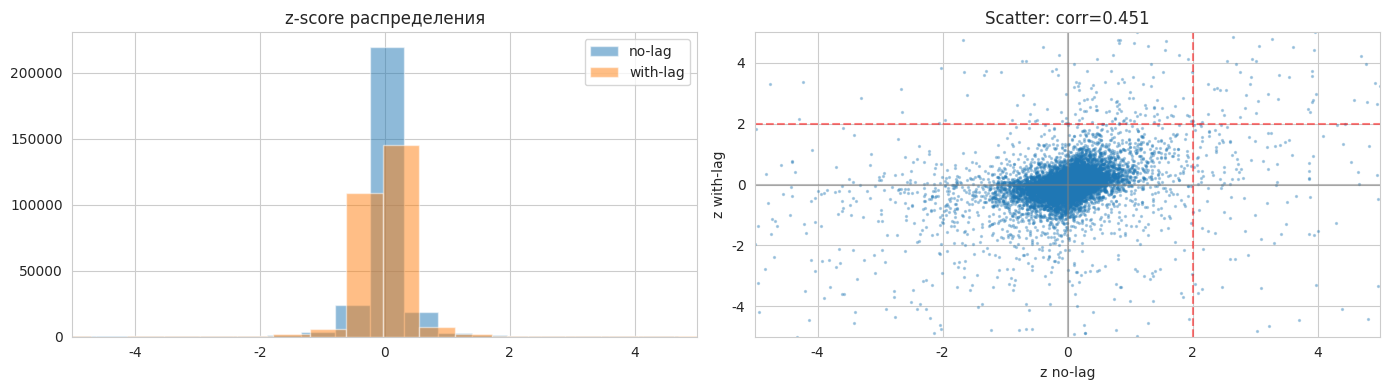

In [2]:
# Корреляция по top-quintile bonds (где сигнал самый сильный)
top_nl = sig[sig['mispricing_quintile_nl'] == 5]
top_wl = sig[sig['mispricing_quintile_wl'] == 5]

# Пересечение Q5 обеих моделей (по (date, isin))
merged_q5 = pd.merge(
    top_nl[['date', 'isin']],
    top_wl[['date', 'isin']],
    on=['date', 'isin']
)
print(f'Total no-lag Q5 observations: {len(top_nl):,}')
print(f'Total with-lag Q5 observations: {len(top_wl):,}')
print(f'Intersection (in both Q5): {len(merged_q5):,}')
print(f'Overlap rate vs no-lag Q5: {len(merged_q5) / len(top_nl):.1%}')

# Distribution of avg_z
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(sig['mispricing_z_nl'].dropna(), bins=80, alpha=0.5, label='no-lag', color='tab:blue')
axes[0].hist(sig['mispricing_z_wl'].dropna(), bins=80, alpha=0.5, label='with-lag', color='tab:orange')
axes[0].set_title('z-score распределения')
axes[0].legend()
axes[0].set_xlim(-5, 5)

from scipy.stats import gaussian_kde
df_ze = sig[['mispricing_z_nl', 'mispricing_z_wl']].dropna()
sample = df_ze.sample(min(30000, len(df_ze)))
axes[1].scatter(sample['mispricing_z_nl'], sample['mispricing_z_wl'], s=2, alpha=0.3)
axes[1].set_xlabel('z no-lag')
axes[1].set_ylabel('z with-lag')
axes[1].set_title(f'Scatter: corr={df_ze.corr().iloc[0,1]:.3f}')
axes[1].axhline(0, color='gray', alpha=0.5); axes[1].axvline(0, color='gray', alpha=0.5)
axes[1].axhline(2, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(2, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlim(-5, 5); axes[1].set_ylim(-5, 5)

plt.tight_layout()
plt.savefig(FIG_DIR / '11_ensemble_diagnostic.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 3. Бэктест 5 ensemble variants

In [3]:
# Подготовка дополнительных filter masks
# V11c: z_nl > 1.5 AND z_wl > 1.0
mask_v11c = (main['mispricing_z_nl'] > 1.5) & (main['mispricing_z_wl'] > 1.0) & mask_quality
# V11d: disagreement filter — keep если SIGN совпадает (both > 0 or both < 0)
mask_agree = ((main['mispricing_z_nl'] > 0) & (main['mispricing_z_wl'] > 0)) | \
             ((main['mispricing_z_nl'] < 0) & (main['mispricing_z_wl'] < 0))
mask_v11d = mask_agree & mask_quality

variants_config = [
    # name, ranking_col, filter, freq, sn, sizing
    ('Baseline V10c quarterly eq',    'mispricing_nl',  mask_quality, 'Q', False, 'equal'),
    ('V11a avg_z monthly',             'mispricing_avg_z', mask_quality, 'M', False, 'equal'),
    ('V11b intersection Q5 monthly',   'mispricing_nl',  mask_quality, 'M', False, 'equal'),  # filter applied separately
    ('V11c z_nl>1.5 AND z_wl>1.0',     'mispricing_nl',  mask_v11c,    'M', False, 'equal'),
    ('V11d disagreement filter',        'mispricing_nl',  mask_v11d,    'M', False, 'equal'),
    ('V11e avg_z + Q + zw (combo W2)',  'mispricing_avg_z', mask_quality, 'Q', False, 'z_weighted'),
    ('V11f avg_z quarterly',             'mispricing_avg_z', mask_quality, 'Q', False, 'equal'),
]

# Для V11b: дополнительный intersection-фильтр
intersection_mask = (main['mispricing_quintile_nl'] == 5) & (main['mispricing_quintile_wl'] == 5) & mask_quality

all_rets = {}
all_metrics = []

for cfg in variants_config:
    name, rank_col, mask, freq, sn, sz = cfg
    if 'V11b' in name:
        mask = intersection_mask
    rets, _ = sl.backtest_rule_c(
        main, n_max=25, freq=freq, ranking_col=rank_col,
        filter_mask=mask, sector_neutral=sn, sizing=sz,
    )
    all_rets[name] = rets
    m = sl.calc_metrics(rets, name=name)
    m['ranking'] = rank_col
    m['freq'] = freq
    m['sizing'] = sz
    all_metrics.append(m)
    print(f'{name:42s}: Sharpe={m["Sharpe"]:.3f}, CAGR={m["CAGR"]*100:5.2f}%, '
          f'n_pos={m["avg_n_positions"]:5.1f}, profit={m["profit_RUB"]:>11,.0f}')

metrics_df = pd.DataFrame(all_metrics)
metrics_df[['name', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB',
            'avg_n_positions']].round(4)

Baseline V10c quarterly eq                : Sharpe=1.134, CAGR= 6.77%, n_pos= 16.6, profit=  3,426,555


V11a avg_z monthly                        : Sharpe=0.979, CAGR= 5.72%, n_pos= 15.6, profit=  2,959,526
V11b intersection Q5 monthly              : Sharpe=1.111, CAGR= 6.77%, n_pos=  2.5, profit=  3,569,796
V11c z_nl>1.5 AND z_wl>1.0                : Sharpe=3.941, CAGR= 3.41%, n_pos=  1.5, profit=    840,962


V11d disagreement filter                  : Sharpe=0.976, CAGR= 5.83%, n_pos= 12.2, profit=  3,019,234


V11e avg_z + Q + zw (combo W2)            : Sharpe=1.202, CAGR= 7.47%, n_pos= 16.6, profit=  3,826,103


V11f avg_z quarterly                      : Sharpe=1.136, CAGR= 6.77%, n_pos= 16.6, profit=  3,426,163


,name,Sharpe,CAGR,MaxDD,profit_RUB,avg_n_positions
0,Baseline V10c quarterly eq,1.1336,0.0677,-0.1420,3.426555e+06,16.6038
1,V11a avg_z monthly,0.9787,0.0572,-0.1387,2.959526e+06,15.5686
2,V11b intersection Q5 monthly,1.1109,0.0677,-0.1403,3.569796e+06,2.5164
3,V11c z_nl>1.5 AND z_wl>1.0,3.9408,0.0341,-0.0144,8.409620e+05,1.5000
4,V11d disagreement filter,0.9763,0.0583,-0.1232,3.019234e+06,12.1536
5,V11e avg_z + Q + zw (combo W2),1.2015,0.0747,-0.1402,3.826103e+06,16.6038
6,V11f avg_z quarterly,1.1360,0.0677,-0.1420,3.426163e+06,16.6038


## Часть 4. Alpha vs RUCBTRNS

In [4]:
alpha_rows = []
for name, rets in all_rets.items():
    r = sl.compare_to_benchmark(rets, bench, bench_col='rucbtrns_ret', name=name)
    alpha_rows.append(r)
alpha_df = pd.DataFrame(alpha_rows)
alpha_df[['name', 'alpha_annual', 'alpha_t_stat', 'alpha_p_value', 'IR', 'beta']].round(4)

,name,alpha_annual,alpha_t_stat,alpha_p_value,IR,beta
0,Baseline V10c quarterly eq,-0.0239,-1.1651,0.2440,-0.4359,1.0977
1,V11a avg_z monthly,-0.0288,-1.7333,0.0830,-0.5910,1.0960
2,V11b intersection Q5 monthly,0.0059,0.1819,0.8557,0.2138,1.0857
3,V11c z_nl>1.5 AND z_wl>1.0,0.1605,2.3737,0.0176,-1.0353,0.2697
4,V11d disagreement filter,-0.0272,-1.7647,0.0776,-0.5266,1.0896
5,V11e avg_z + Q + zw (combo W2),-0.0182,-0.8256,0.4090,-0.2296,1.1095
6,V11f avg_z quarterly,-0.0237,-1.1637,0.2446,-0.4375,1.0954


## Часть 5. Sub-period stability

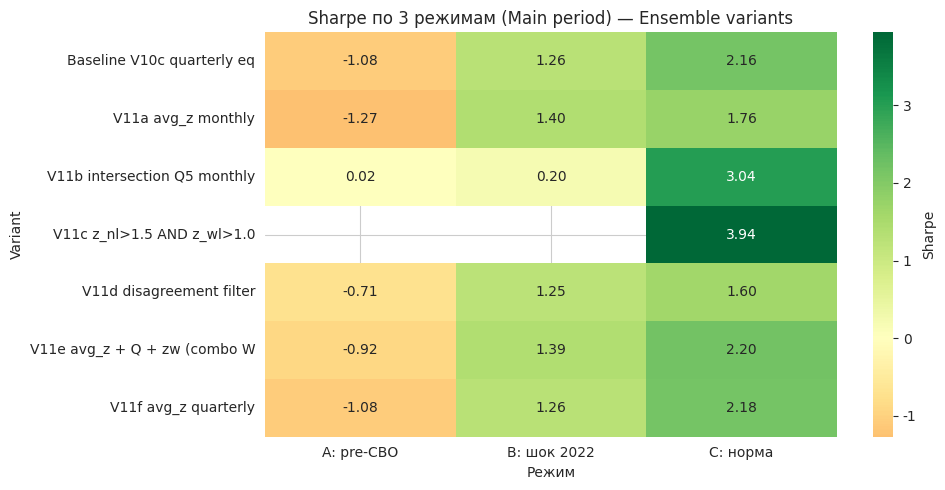

In [5]:
sub_rows = []
for name, rets in all_rets.items():
    sub = sl.sub_period_metrics(rets, variant_name=name)
    sub_rows.append(sub)
sub_df = pd.concat(sub_rows, ignore_index=True)

tbl = sub_df.copy()
tbl['variant'] = tbl['name'].apply(lambda s: s.split('|')[0].strip()[:28])
tbl['regime'] = tbl['name'].apply(lambda s: s.split('|')[1].strip() if '|' in s else '')
pivot = tbl.pivot(index='variant', columns='regime', values='Sharpe')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Sharpe'}, ax=ax)
ax.set_title('Sharpe по 3 режимам (Main period) — Ensemble variants')
ax.set_xlabel('Режим'); ax.set_ylabel('Variant')
plt.tight_layout()
plt.savefig(FIG_DIR / '11_subperiod_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 6. Сводная таблица в RUB

In [6]:
summary = metrics_df[['name', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB', 'avg_n_positions']].copy()
summary = summary.merge(
    alpha_df[['name', 'alpha_annual', 'alpha_t_stat', 'IR', 'sharpe_diff_p_value']],
    on='name')

summary['profit_M_RUB'] = (summary['profit_RUB'] / 1e6).round(2)
summary['CAGR_pct'] = (summary['CAGR'] * 100).round(2)
summary['MaxDD_pct'] = (summary['MaxDD'] * 100).round(2)
summary['alpha_pct'] = (summary['alpha_annual'] * 100).round(2)
summary['Sharpe'] = summary['Sharpe'].round(3)
summary['IR'] = summary['IR'].round(3)
summary['alpha_t_stat'] = summary['alpha_t_stat'].round(2)
summary['sharpe_diff_p'] = summary['sharpe_diff_p_value'].round(3)

disp = summary[['name', 'Sharpe', 'CAGR_pct', 'MaxDD_pct',
                'profit_M_RUB', 'alpha_pct', 'alpha_t_stat', 'IR', 'sharpe_diff_p']]
print('NB 11 SUMMARY: Ensemble (no-lag + with-lag)')
print('(Main 4.66y, 10М RUB старт, vs RUCBTRNS)')
print()
print(disp.to_string(index=False))

NB 11 SUMMARY: Ensemble (no-lag + with-lag)
(Main 4.66y, 10М RUB старт, vs RUCBTRNS)

                          name  Sharpe  CAGR_pct  MaxDD_pct  profit_M_RUB  alpha_pct  alpha_t_stat     IR  sharpe_diff_p
    Baseline V10c quarterly eq   1.134      6.77     -14.20          3.43      -2.39         -1.17 -0.436          0.984
            V11a avg_z monthly   0.979      5.72     -13.87          2.96      -2.88         -1.73 -0.591          0.979
  V11b intersection Q5 monthly   1.111      6.77     -14.03          3.57       0.59          0.18  0.214          0.768
    V11c z_nl>1.5 AND z_wl>1.0   3.941      3.41      -1.44          0.84      16.05          2.37 -1.035            NaN
      V11d disagreement filter   0.976      5.83     -12.32          3.02      -2.72         -1.76 -0.527          0.979
V11e avg_z + Q + zw (combo W2)   1.202      7.47     -14.02          3.83      -1.82         -0.83 -0.230          0.961
          V11f avg_z quarterly   1.136      6.77     -14.20        

## Часть 7. Сохранение

In [7]:
metrics_df.to_csv(sl.DATA_DIR / 'nb11_metrics.csv', index=False)
alpha_df.to_csv(sl.DATA_DIR / 'nb11_alpha.csv', index=False)
sub_df.to_csv(sl.DATA_DIR / 'nb11_subperiod.csv', index=False)
summary.to_csv(sl.DATA_DIR / 'nb11_summary.csv', index=False)

rets_combined = []
for name, rets in all_rets.items():
    r = rets.copy()
    r['variant'] = name
    rets_combined.append(r)
pd.concat(rets_combined, ignore_index=True).to_csv(
    sl.DATA_DIR / 'nb11_returns.csv', index=False)

print('Saved nb11_*.csv (6 files)')

Saved nb11_*.csv (6 files)


## Часть 8. Итоги

**Гипотезы:**
- avg_z (V11a) сглаживает шум каждой модели
- intersection (V11b) — restrictive, мало позиций, высокая precision
- conditional thresholds (V11c) — баланс
- disagreement filter (V11d) — исключаем bonds, где модели спорят
- combo W2 (V11e) — ensemble + всё лучшее из NB 10

**Если ни один variant не превышает V10f (Sharpe 1.10), Quality+Quarterly+Z-weighted уже близко к потолку для этого setup → ensemble не помогает, негативный finding.**